In [1]:
import os
import sys
import matplotlib
import matplotlib.pyplot
import matplotlib.pyplot as plt

import time
import datetime
import argparse
import numpy as np
import pandas as pd
from random import SystemRandom
from sklearn import model_selection

import torch
import torch.nn as nn
from torch.nn.functional import relu
import torch.optim as optim
from torch.distributions import uniform


In [2]:
n = 3000
sample_tp = None
cut_tp = None
timepoints = 1000
extrap = False
max_t = 5
noise_weight = 0.0


In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

random_seed = 0
torch.manual_seed(random_seed)
np.random.seed(random_seed)

In [4]:
def get_next_val(init, t, tmin, tmax, final = None):
    if final is None:
        return init
    val = init + (final - init) / (tmax - tmin) * t
    return val

def generate_periodic(time_steps, init_freq, init_amplitude, starting_point, 
    final_freq = None, final_amplitude = None, phi_offset = 0.):

    tmin = time_steps.min()
    tmax = time_steps.max()

    data = []
    t_prev = time_steps[0]
    phi = phi_offset
    for t in time_steps:
        dt = t - t_prev
        amp = get_next_val(init_amplitude, t, tmin, tmax, final_amplitude)
        freq = get_next_val(init_freq, t, tmin, tmax, final_freq)
        phi = phi + 2 * np.pi * freq * dt # integrate to get phase

        y = amp * np.sin(phi) + starting_point
        t_prev = t
        data.append([t,y])
    return np.array(data)

def assign_value_or_sample(value, sampling_interval = [0.,1.]):
    if value is None:
        int_length = sampling_interval[1] - sampling_interval[0]
        return np.random.random() * int_length + sampling_interval[0]
    else:
        return value

class TimeSeries:
    def __init__(self, device = torch.device("cpu")):
        self.device = device
        self.z0 = None

    def init_visualization(self):
        self.fig = plt.figure(figsize=(10, 4), facecolor='white')
        self.ax = self.fig.add_subplot(111, frameon=False)
        plt.show(block=False)

    def visualize(self, truth):
        self.ax.plot(truth[:,0], truth[:,1])

    def add_noise(self, traj_list, time_steps, noise_weight):
        n_samples = traj_list.size(0)

        # Add noise to all the points except the first point
        #n_tp = len(time_steps) - 1
        n_tp = time_steps.shape[1] - 1
        noise = np.random.sample((n_samples, n_tp))
        noise = torch.Tensor(noise).to(self.device)

        traj_list_w_noise = traj_list.clone()
        # Dimension [:,:,0] is a time dimension -- do not add noise to that
        traj_list_w_noise[:,1:,0] += noise_weight * noise
        return traj_list_w_noise



class Periodic_1d(TimeSeries):
    def __init__(self, device = torch.device("cpu"), init_freq = 0.3, init_amplitude = 1.,
        final_amplitude = 10., final_freq = 1., z0 = 0.):
        super(Periodic_1d, self).__init__(device)

        self.init_freq = init_freq
        self.init_amplitude = init_amplitude
        self.final_amplitude = final_amplitude
        self.final_freq = final_freq
        self.z0 = z0

    def sample_traj(self, time_steps, n_samples = 1, noise_weight = 1., cut_out_section = None):
        # Sample periodic functions. 
        traj_list = []
        for i in range(n_samples):
            init_freq = assign_value_or_sample(self.init_freq, [0.4,0.8])
            if self.final_freq is None:
                final_freq = init_freq
            else:
                final_freq = assign_value_or_sample(self.final_freq, [0.4,0.8])
            init_amplitude = assign_value_or_sample(self.init_amplitude, [0.,1.])
            final_amplitude = assign_value_or_sample(self.final_amplitude, [0.,1.])

            noisy_z0 = self.z0 + np.random.normal(loc=0., scale=0.1)

            traj = generate_periodic(time_steps[i], init_freq = init_freq, 
                init_amplitude = init_amplitude, starting_point = noisy_z0, 
                final_amplitude = final_amplitude, final_freq = final_freq)

            # Cut the time dimension
            traj = np.expand_dims(traj[:,1:], 0)
            traj_list.append(traj)

        # shape: [n_samples, n_timesteps, 2]
        # traj_list[:,:,0] -- time stamps
        # traj_list[:,:,1] -- values at the time stamps
        traj_list = np.array(traj_list)
        traj_list = torch.Tensor().new_tensor(traj_list, device = self.device)
        traj_list = traj_list.squeeze(1)

        traj_list = self.add_noise(traj_list, time_steps, noise_weight)
        return traj_list
    
def add_mask(data_dict):
    data = data_dict["observed_data"]
    mask = data_dict["observed_mask"]
    if mask is None:
        mask = torch.ones_like(data).to(get_device(data))
    data_dict["observed_mask"] = mask
    return data_dict

def split_data_interp(data_dict):
    device = get_device(data_dict["data"])
    split_dict = {"observed_data": data_dict["data"][...,:-1].clone(),
                "observed_tp": data_dict["data"][...,-1].clone(),
                "data_to_predict": data_dict["data"][...,:-1].clone(),
                "tp_to_predict": data_dict["data"][...,-1].clone()}

    split_dict["observed_mask"] = None 
    split_dict["mask_predicted_data"] = None 
    split_dict["labels"] = None 

    if "mask" in data_dict and data_dict["mask"] is not None:
        split_dict["observed_mask"] = data_dict["mask"].clone()
        split_dict["mask_predicted_data"] = data_dict["mask"].clone()

    if ("labels" in data_dict) and (data_dict["labels"] is not None):
        split_dict["labels"] = data_dict["labels"].clone()

    split_dict["mode"] = "interp"
    return split_dict
    
def split_and_subsample_batch(data_dict, data_type = "train"):
    if data_type == "train":
        processed_dict = split_data_interp(data_dict)
    else:
        processed_dict = split_data_interp(data_dict)
    
    # add mask
    processed_dict = add_mask(processed_dict)
        
    return processed_dict

def basic_collate_fn(batch, device = device, data_type = "train"):
    batch = torch.stack(batch)
    data_dict = {"data": batch}
    data_dict = split_and_subsample_batch(data_dict, data_type = data_type)
    return data_dict

def get_dict_template():
    return {"observed_data": None, "observed_tp": None, "data_to_predict": None,
            "tp_to_predict": None, "observed_mask": None, "mask_predicted_data": None, "labels": None}

def get_next_batch(dataloader):
    # Make the union of all time points and perform normalization across the whole dataset
    data_dict = dataloader.__next__()
    batch_dict = get_dict_template()

    # remove the time points where there are no observations in this batch
    non_missing_tp = torch.sum(data_dict["observed_data"],(0,2)) != 0.
    batch_dict["observed_data"] = data_dict["observed_data"][:, non_missing_tp]
    batch_dict["observed_tp"] = data_dict["observed_tp"][:, non_missing_tp]

    if ("observed_mask" in data_dict) and (data_dict["observed_mask"] is not None):
        batch_dict["observed_mask"] = data_dict["observed_mask"][:, non_missing_tp]

    batch_dict[ "data_to_predict"] = data_dict["data_to_predict"]
    batch_dict["tp_to_predict"] = data_dict["tp_to_predict"]

    non_missing_tp = torch.sum(data_dict["data_to_predict"],(0,2)) != 0.
    batch_dict["data_to_predict"] = data_dict["data_to_predict"][:, non_missing_tp]
    batch_dict["tp_to_predict"] = data_dict["tp_to_predict"][:, non_missing_tp]

    if ("mask_predicted_data" in data_dict) and (data_dict["mask_predicted_data"] is not None):
        batch_dict["mask_predicted_data"] = data_dict["mask_predicted_data"][:, non_missing_tp]

    batch_dict["mode"] = data_dict["mode"]
    return batch_dict


In [5]:
n_total_tp = timepoints

'''
distribution = uniform.Uniform(torch.Tensor([0.0]),torch.Tensor([max_t]))
time_steps =  distribution.sample(torch.Size([n, n_total_tp-1]))[...,0]
time_steps = torch.cat((torch.zeros(n, 1), time_steps), axis=1)
time_steps = torch.sort(time_steps,axis=1)[0]
for i in range(n):
    for j in range(timepoints-1):
        if time_steps[i,j+1] == time_steps[i,j]:
            time_steps[i,j+1] += 0.0001
            print(i,j)
            print(time_steps[i,j+1], time_steps[i,j])
'''
time_steps = torch.linspace(0, max_t, timepoints).unsqueeze(0).repeat(n,1)

dataset_obj = Periodic_1d(init_freq = None, init_amplitude = 1., final_amplitude = 1., final_freq = None, z0 = 1.)
dataset = dataset_obj.sample_traj(time_steps, n_samples = n, noise_weight = noise_weight)



In [6]:
print(dataset.shape, time_steps.shape)

dataset_it = torch.cat((dataset,time_steps.unsqueeze(-1)), axis=-1)
print(dataset_it.shape)
np.save("period.npy", dataset_it)


torch.Size([3000, 1000, 1]) torch.Size([3000, 1000])
torch.Size([3000, 1000, 2])


In [7]:
dataset = np.load('period.npy')
print(dataset.shape)


(3000, 1000, 2)


In [8]:
t = dataset[:,:,-1]
for i in range(t.shape[0]):
    for j in range(t.shape[1]-1):
        if t[i,j+1] == t[i,j]:
            print(i,j)

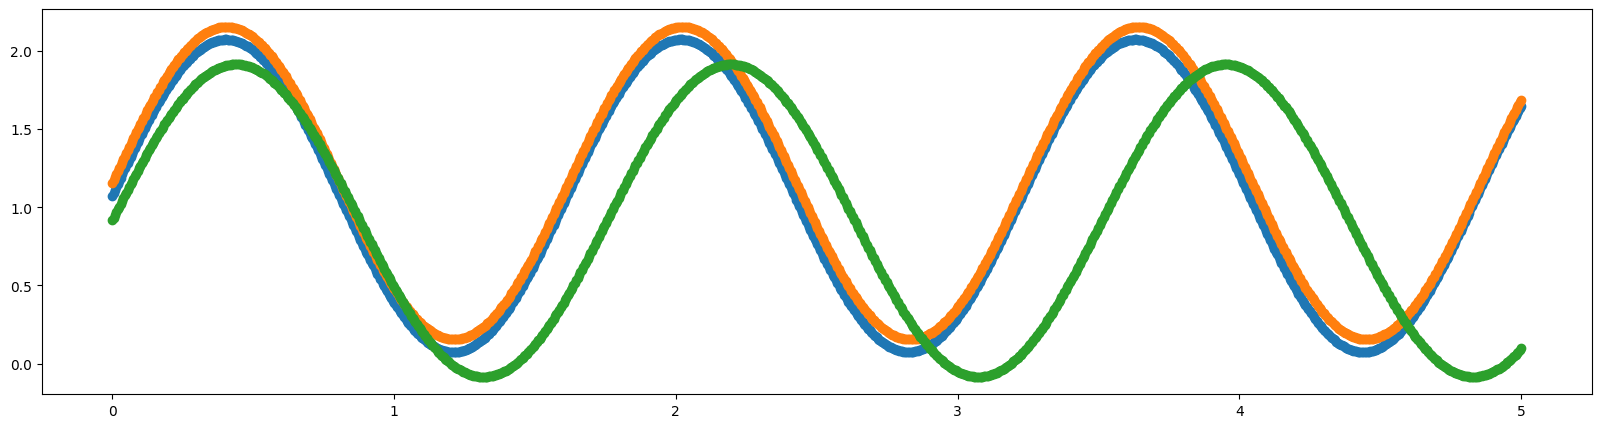

In [9]:
inds = [0,1,2]
fig = plt.figure(figsize = (20,5))
for ind in inds:
    plt.plot(dataset[ind,:,-1], dataset[ind,:,0],'o--')

In [10]:
obs_ratio = 0.1
dataset_GT = torch.tensor(np.load('period.npy')).float()
n, T, d = dataset_GT.shape

observed_points = int(T * obs_ratio)
dataset_GT_mask = torch.zeros(n, observed_points, dataset_GT.shape[-1])
mask = np.zeros((n,T), dtype=int)
for i in range(n):
    observed_indices = np.random.choice(np.arange(1,T), observed_points-1, replace=False)
    sorted_indices = np.sort(observed_indices)
    mask[i, 0] = 1
    mask[i, observed_indices] = 1
    dataset_GT_mask[i,0] = dataset_GT[i,0]
    dataset_GT_mask[i,1:] = dataset_GT[i,sorted_indices]
mask = torch.tensor(mask)    

In [11]:
print(dataset_GT_mask.shape)
np.save("period.npy", dataset_GT_mask)

torch.Size([3000, 100, 2])
